# Exploratory Data Analysis
Exploratory Data Analysis (EDA) is the process of examining datasets to summarize their key characteristics, detect issues, and assess readiness for deeper analysis. By applying statistical methods and visualizations, EDA guides data preparation and helps determine suitable techniques for modeling. The cleaned dataset produced through EDA will serve as the input for feature engineering, enabling the creation of meaningful variables for machine learning workflows.

We will proceed step by step: 
- Load 
- Inspect 
- Summarize 
- Visualize 
- Derive features

The dataset used in this notebook is sourced from [Kaggle](https://www.kaggle.com/datasets/imtkaggleteam/diabetes) and contains health-related attributes for diabetes analysis.


**1. Import Libraries**

In [0]:
# Import libraries
from pyspark.sql.functions import col, mean,  median, expr, sum, stddev, corr, countDistinct, when  
import matplotlib.pyplot as plt
import seaborn as sns

**2. Load Data**

In [0]:
# load data to dataframe and display 
df = spark.table('workspace.default.diabetes_data_cleaned')
display(df.limit(5))

patient_id,cholesterol_total,stabilized_glucose,hdl_cholesterol,chol_hdl_ratio,hba1c_percent,location,age,gender,height_inches,weight_pounds,body_frame,systolic_bp_1,diastolic_bp_1,waist_inches,hip_inches,minutes_post_meal
1000,203.0,82.0,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,29.0,38.0,720
1001,165.0,97.0,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,46.0,48.0,360
1002,228.0,92.0,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,49.0,57.0,180
1003,78.0,93.0,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,33.0,38.0,480
1005,249.0,90.0,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,44.0,41.0,300


**3. Inspect Schema & Column Types**

In [0]:
# Print schema to check column names and types
df.printSchema()

# Separate numeric and categorical columns
numeric_cols = [f.name for f in df.schema.fields if f.dataType.simpleString() in ["int","double","float","long"] and f.name != "patient_id"]
categorical_cols = [f.name for f in df.schema.fields if f.dataType.simpleString() == "string"]


root
 |-- patient_id: integer (nullable = true)
 |-- cholesterol_total: float (nullable = true)
 |-- stabilized_glucose: float (nullable = true)
 |-- hdl_cholesterol: float (nullable = true)
 |-- chol_hdl_ratio: float (nullable = true)
 |-- hba1c_percent: float (nullable = true)
 |-- location: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- height_inches: float (nullable = true)
 |-- weight_pounds: float (nullable = true)
 |-- body_frame: string (nullable = true)
 |-- systolic_bp_1: float (nullable = true)
 |-- diastolic_bp_1: float (nullable = true)
 |-- waist_inches: float (nullable = true)
 |-- hip_inches: float (nullable = true)
 |-- minutes_post_meal: integer (nullable = true)



**4. Numerical Variable Exploration**

In [0]:
# Summary of numeric features
df.select(numeric_cols).summary().display()

summary,cholesterol_total,stabilized_glucose,hdl_cholesterol,chol_hdl_ratio,hba1c_percent,age,height_inches,weight_pounds,systolic_bp_1,diastolic_bp_1,waist_inches,hip_inches,minutes_post_meal
count,388,388,388,388,388,388,388,388,388,388,388,388,388
mean,208.15463917525773,106.91494845360825,50.61340206185567,4.520103092967849,5.577190729760632,47.04896907216495,66.03350515463917,178.1262886597938,137.19072164948454,83.41237113402062,37.95618556701031,43.09278350515464,340.33505154639175
stddev,44.41804931598672,53.33047941247351,17.398061187928647,1.7440509253497727,2.1835709385577853,16.52607911526826,3.90803995791175,40.4552520794975,22.914281713695956,13.552274199014082,5.742145552117547,5.6506064694321765,309.7248359652363
min,78.0,48.0,12.0,1.5,2.68,19,52.0,99.0,90.0,48.0,26.0,30.0,5
25%,179.0,81.0,38.0,3.2,4.4,34,63.0,151.0,121.0,75.0,33.0,39.0,90
50%,204.0,89.0,46.0,4.2,4.84,45,66.0,173.0,136.0,82.0,37.0,42.0,240
75%,230.0,106.0,59.0,5.4,5.6,60,69.0,200.0,148.0,90.0,41.0,46.0,480
max,443.0,385.0,120.0,19.3,16.11,92,76.0,325.0,250.0,124.0,56.0,64.0,1560


Derive **BMI** and **Waist-to-Hip Ratio** features using height, weight, waist, and hip measurements.

Waist‑to‑hip ratio
- Measures central (abdominal) obesity.
- A higher ratio indicates more fat around the waist relative to hips, which is strongly linked to insulin resistance and type 2 diabetes risk.
- Ratios >0.9 (men) or >0.85 (women) are considered high risk.

BMI 
- Body Mass Index is a general measure of obesity.
- Overweight (BMI ≥25) and obese (BMI ≥30) individuals have a much higher likelihood of developing type 2 diabetes.

In [0]:
# Add metric conversions and derived features 
df2 = (
  df.withColumn("BMI", (col("weight_pounds") * 0.453592) / (col("height_inches") * 0.0254)**2)
  .withColumn("waist_hip_ratio", col("waist_inches") / col("hip_inches"))
  .drop("height_inches", "weight_pounds", "waist_inches", "hip_inches")
)

In [0]:
# Update numeric columns and show summary
numeric_cols = [f.name for f in df2.schema.fields if f.dataType.simpleString() in ["int","double","float","long"] and f.name != "patient_id"]
df2.select(numeric_cols).summary().display()

summary,cholesterol_total,stabilized_glucose,hdl_cholesterol,chol_hdl_ratio,hba1c_percent,age,systolic_bp_1,diastolic_bp_1,minutes_post_meal,BMI,waist_hip_ratio
count,388,388,388,388,388,388,388,388,388,388,388
mean,208.15463917525773,106.91494845360825,50.61340206185567,4.520103092967849,5.577190729760632,47.04896907216495,137.19072164948454,83.41237113402062,340.33505154639175,28.82792828524511,0.881149251516847
stddev,44.41804931598672,53.33047941247351,17.398061187928647,1.7440509253497727,2.1835709385577853,16.52607911526826,22.914281713695956,13.552274199014082,309.7248359652363,6.625078012859253,0.07294239999529044
min,78.0,48.0,12.0,1.5,2.68,19,90.0,48.0,5,16.00349975391309,0.6818181818181818
25%,179.0,81.0,38.0,3.2,4.4,34,121.0,75.0,90,24.119542647639538,0.8292682926829268
50%,204.0,89.0,46.0,4.2,4.84,45,136.0,82.0,240,27.78994651480427,0.8809523809523809
75%,230.0,106.0,59.0,5.4,5.6,60,148.0,90.0,480,32.23949587228981,0.925
max,443.0,385.0,120.0,19.3,16.11,92,250.0,124.0,1560,55.78550463741552,1.1428571428571428


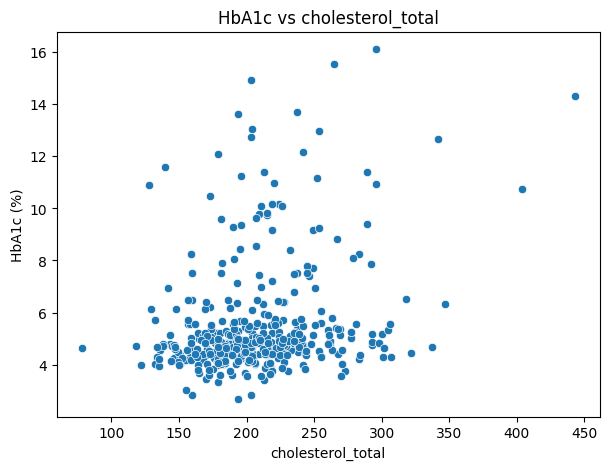

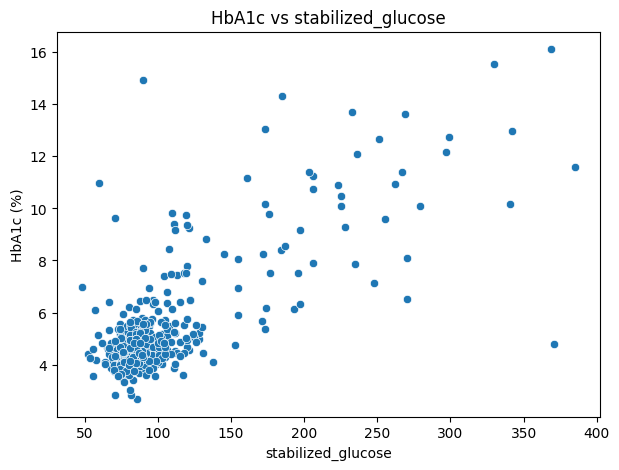

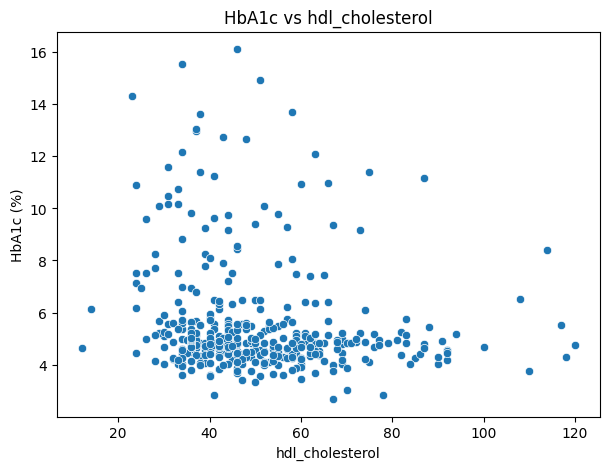

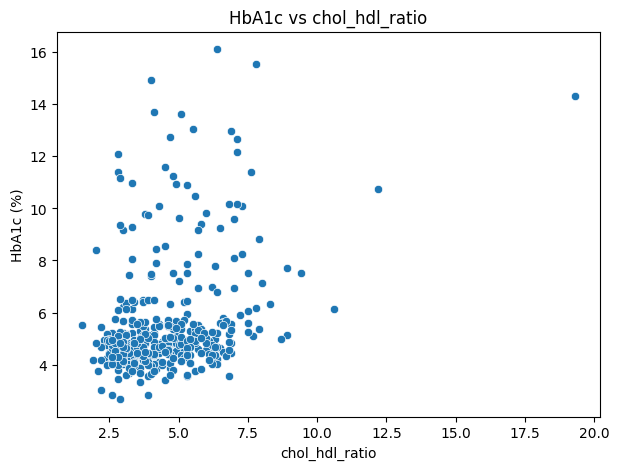

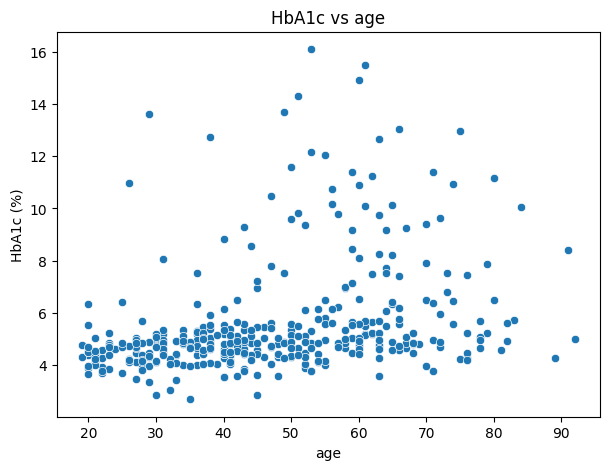

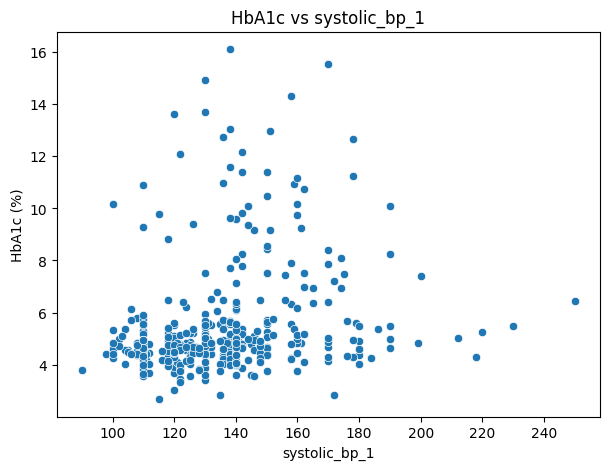

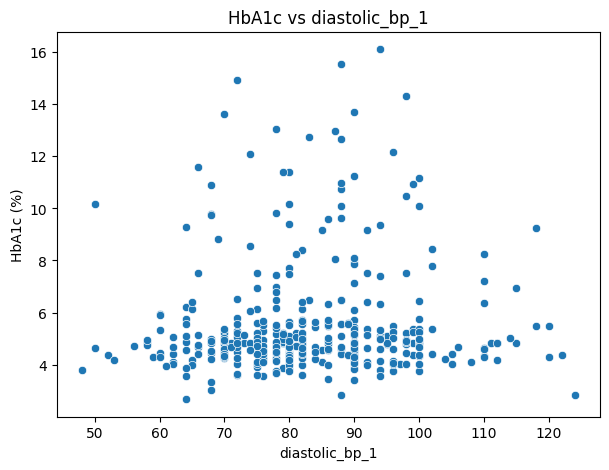

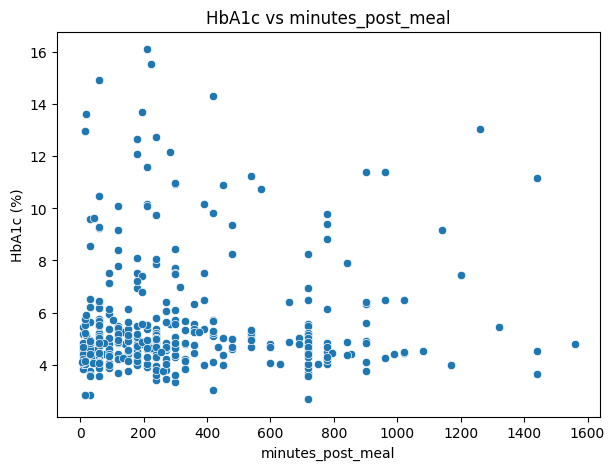

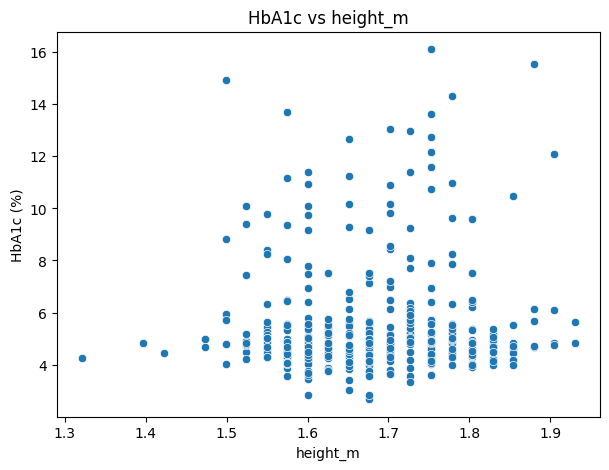

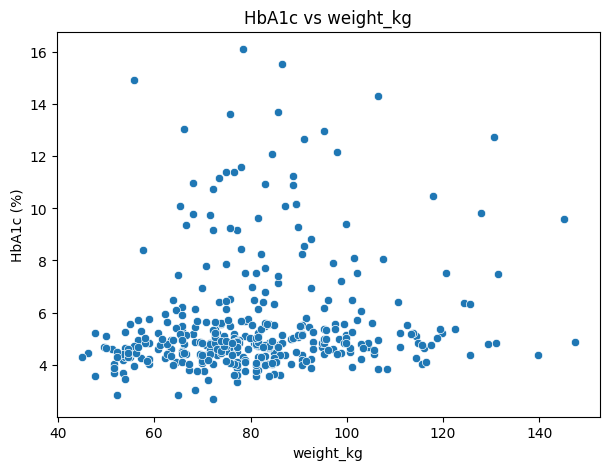

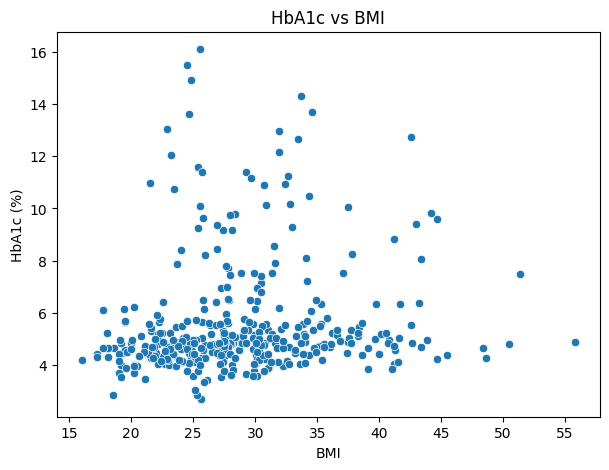

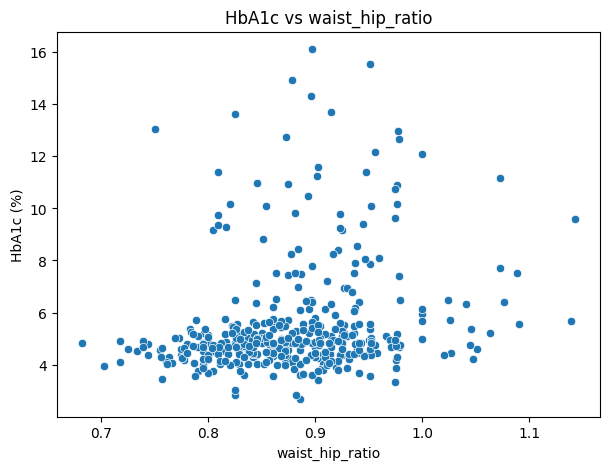

In [0]:
# Convert numeric features to Pandas for plotting
pdf = df2.select(numeric_cols).toPandas()

# Scatter plots: HbA1c vs each numeric feature
for c in numeric_cols:
    if c != "hba1c_percent":
        plt.figure(figsize=(7,5))
        sns.scatterplot(x=pdf[c], y=pdf["hba1c_percent"])
        plt.title(f"HbA1c vs {c}")
        plt.xlabel(c)
        plt.ylabel("HbA1c (%)")
        plt.show()


The column `chol_hdl_ratio` contains outliers. To address this, we apply the **Z‑score method** to identify and remove values that fall beyond ±5 standard deviations from the mean.

In [0]:
# Step 1: Calculate mean and standard deviation for cholesterol_total
mean_val = df2.select(mean(col("chol_hdl_ratio"))).collect()[0][0]
std_val = df2.select(stddev(col("chol_hdl_ratio"))).collect()[0][0]

# Step 2: normal threshold used is 3 but we use 5 to remove the most one extreme outlier in the visualization
threshold = 5

# Step 3: Filter out outliers
df3 = df2.filter(((col("chol_hdl_ratio") - mean_val) / std_val).between(-threshold, threshold)
)

# Step 4: Compare counts before and after cleaning
print("Original count:", df2.count())
print("Cleaned count:", df3.count())

Original count: 388
Cleaned count: 387


In [0]:
# Correlation of HbA1c with other numeric features
for c in numeric_cols:
    if c != "hba1c_percent":
        print(c, df3.stat.corr("hba1c_percent", c))

cholesterol_total 0.223981245041385
stabilized_glucose 0.7458190995026719
hdl_cholesterol -0.1398414044052792
chol_hdl_ratio 0.2932360284936633
age 0.3332723841427989
systolic_bp_1 0.19688487005403138
diastolic_bp_1 0.03694206508929753
minutes_post_meal 0.029169347217682776
BMI 0.11974743415667412
waist_hip_ratio 0.22044150209402955


**Conclusion:**  
HbA1c percent shows the strongest correlation with stabilized glucose, confirming its role as the primary predictor of diabetes. Moderate associations are observed with age, cholesterol/HDL ratio, cholesterol total, waist size, and systolic blood pressure, while HDL cholesterol is negatively correlated, reflecting its protective effect. Other features such as height, hip size, and minutes post meal show negligible influence and can be deprioritized in feature selection.

**5. Categorical Variable Exploration**

In [0]:
# Frequency counts for categorical features
for c in categorical_cols:
    df3.groupBy(c).count().orderBy("count", ascending=False).display()

location,count
Louisa,197
Buckingham,190


gender,count
female,225
male,162


body_frame,count
medium,187
large,100
small,100


**7. Cross-tab categorical**

Cross-Tab Analysis: Categorical Features vs HbA1c

We derive an **`hba1c_category`** column by grouping HbA1c values into three ranges:  
- Normal (< 5.7%)  
- Prediabetic (5.7–6.4%)  
- Diabetic (≥ 6.5%)  

We perform cross-tabulation between each categorical feature and the HbA1c categories to show how patient groups distribute across diabetes risk levels. 


In [0]:
# Cross-tab analysis for categorical features vs HbA1c
df_final = df3.withColumn(
    "hba1c_category",
    when(col("hba1c_percent") < 5.7, "Normal")
    .when((col("hba1c_percent") >= 5.7) & (col("hba1c_percent") < 6.5), "Prediabetic")
    .otherwise("Diabetic")
)
for c in categorical_cols:
    print(f"Cross-tab for {c} vs HbA1c category")
    df_final.crosstab(c, "hba1c_category").display()


Cross-tab for location vs HbA1c category


location_hba1c_category,Diabetic,Normal,Prediabetic
Buckingham,32,141,17
Louisa,30,160,7


Cross-tab for gender vs HbA1c category


gender_hba1c_category,Diabetic,Normal,Prediabetic
female,34,178,13
male,28,123,11


Cross-tab for body_frame vs HbA1c category


body_frame_hba1c_category,Diabetic,Normal,Prediabetic
medium,28,148,11
large,25,67,8
small,9,86,5


In [0]:
df_final2 = df_final.drop("patient_id","hba1c_percent")

In [0]:
#Display the distribution of HbA1c categories
display(df_final2.select("hba1c_category").groupBy("hba1c_category").count())

hba1c_category,count
Normal,301
Diabetic,62
Prediabetic,24


**Final Conclusion**

The EDA process provided a clear understanding of the dataset by exploring numerical and categorical features, engineering BMI and waist-to-hip ratio, and addressing outliers with Z‑score filtering. Key findings show that **HbA1c percent** is most strongly correlated with stabilized glucose, while age, cholesterol ratios, and waist-to-hip ratio offer moderate predictive value. Categorical analysis further highlighted group-level differences in diabetes prevalence.  

The dataset is now **clean, structured, and enriched with derived features**, making it well-prepared for feature engineering and classification modeling.


In [0]:
#write dataset to delta
df_final2.write.mode("overwrite").saveAsTable("diabetes_data_explored")